In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm    
from scipy.stats import chi2_contingency  #  para el Chi-Square test
from scipy.stats.contingency import association # para el Cramer

In [2]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.



1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*




In [3]:

crosstab_result = pd.crosstab(df["category"], df["isBestSeller"])

crosstab_result["proportion_true"] = (
    crosstab_result[True] / (crosstab_result[True] + crosstab_result[False])
)

crosstab_proportion = crosstab_result.sort_values("proportion_true", ascending=False)


print(crosstab_proportion.head(10))
           

isBestSeller                    False  True  proportion_true
category                                                    
Grocery                          9008   556         0.058135
Smart Home Security & Lighting     98     6         0.057692
Health & Personal Care           9017   552         0.057686
Mobile Phone Accessories          248    11         0.042471
Power & Hand Tools               8353   306         0.035339
Billiard, Snooker & Pool          241     8         0.032129
Pet Supplies                     9152   285         0.030200
Home Brewing & Wine Making        239     7         0.028455
Mirrors                           243     7         0.028000
Wind Instruments                  243     7         0.028000


In [4]:
crosstab_proportion.dtypes

isBestSeller
False                int64
True                 int64
proportion_true    float64
dtype: object

In [5]:
lista_bet_sellers = crosstab_proportion.head(10).index # como columns, pero saca el index que ahora mismo son las categorias
top_bet_sellers = list(enumerate(lista_bet_sellers, start=1))
top_bet_sellers


[(1, 'Grocery'),
 (2, 'Smart Home Security & Lighting'),
 (3, 'Health & Personal Care'),
 (4, 'Mobile Phone Accessories'),
 (5, 'Power & Hand Tools'),
 (6, 'Billiard, Snooker & Pool'),
 (7, 'Pet Supplies'),
 (8, 'Home Brewing & Wine Making'),
 (9, 'Mirrors'),
 (10, 'Wind Instruments')]

   
2. **Statistical Tests**:
- Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
- Compute Cramér's V to understand the strength of association between best-seller status and category.

In [6]:
# aqui usamos from scipy.stats import chi2_contingency al inicio

chi2_statistic, chi2_p_value, _, _ = chi2_contingency(crosstab_proportion)

print("Chi-square:", chi2_statistic)
print("p-value:", chi2_p_value)



Chi-square: 36684.237866368574
p-value: 0.0


Con Chi-Square tan grande indica que las categorías NO tienen la misma proporción de best‑sellers. 
P= 0 indica que si afectan a la posibilidad de ser bet seller, pero no en que tamaño influye

Para ello vemos el cramer ahora

In [7]:
crosstab_proportion.columns = crosstab_proportion.columns.map(str)

ct_for_stats = crosstab_proportion[["False", "True"]]


In [8]:
# para esto importamos al inicio from scipy.stats.contingency import association
association(ct_for_stats, method="cramer")




0.1222829439760564

Con cramer = 0,122 ...> 0,05 ---> Aceptamos H0 -> las variables son independientes

3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

<Figure size 600x400 with 0 Axes>

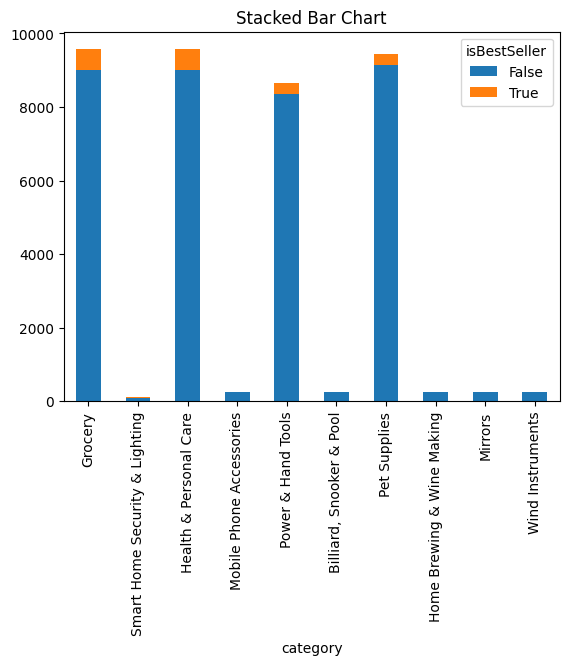

In [9]:
clt_fot_stacked_bar = ct_for_stats.head(10)
plt.figure(figsize=(6,4))
clt_fot_stacked_bar.plot(kind="bar", stacked=True)
plt.title("Stacked Bar Chart")
plt.show()

---

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method.   
    Products priced below the first quartile minus 1.5 times the IQR   
    or  
     above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset.  
     
     The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*


In [10]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")
df.head()


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [11]:
def tukeys_test_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds for the outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify the outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]
     
    return outliers

In [12]:
outliers = tukeys_test_outliers(df['price'])
outliers

10         139.00
19         164.99
25         149.99
28         289.00
31         199.99
            ...  
2443619    166.99
2443627    152.58
2443638    108.77
2443641    166.99
2443643    158.99
Name: price, Length: 327688, dtype: float64

In [13]:
df_clean = df.drop(outliers.index)
df_clean.shape

(2115963, 9)

1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`.  
     Filter out the top 20 categories based on count for better visualization.
   


(1182251, 9)


C:\Users\ernes\AppData\Local\Temp\ipykernel_30664\4048176767.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top20, x='category', y='price', palette="coolwarm")


<Axes: xlabel='category', ylabel='price'>

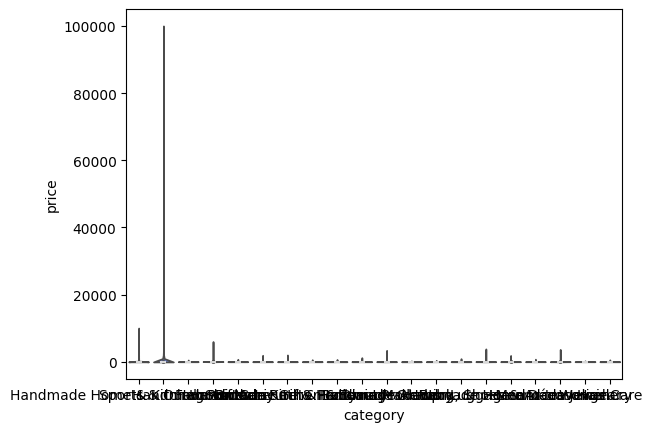

In [14]:
top20_categories = df['category'].value_counts().head(20).index # saca los 20 primeros
filtro_booleano_20 = df['category'].isin(top20_categories) # saca un filtro de una columna para sacar booleanos
df_top20 = df[filtro_booleano_20 ]
print(df_top20.shape)
sns.violinplot(data=df_top20, x='category', y='price', palette="coolwarm")



 - Which product category tends to have the highest median price? Don't filter here by top categories.

In [15]:
median_prices = df.groupby("category")["price"].median().sort_values(ascending=False)
median_prices


category
Laptops                      1042.725
Desktop PCs                   810.400
Snowboards                    366.725
Home Audio Record Players     326.080
3D Printers                   319.000
                               ...   
Adapters                        7.050
Make-up                         7.000
Signs & Plaques                 6.990
Arts & Crafts                   5.990
Office Paper Products           4.380
Name: price, Length: 296, dtype: float64

In [16]:
median_prices.head(1)

category
Laptops    1042.725
Name: price, dtype: float64

---

2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).




In [17]:
top10_categories = df['category'].value_counts().head(10).index # saca los 10 primeros

filtro_booleano_10 = df['category'].isin(top10_categories) # saca un filtro de una columna para sacar booleanos(Serie booleanos)

df_top10 = df[filtro_booleano_10 ] # filtra por esa serie

avg_prices = df_top10.groupby('category')['price'].mean().sort_values(ascending=False) # agrupa por categoria
                                                                                       # selecciona la columna price
                                                                                       # calcula la media por categoria
                                                                                       # ordena de maypr a menor
avg_prices  

category
Sports & Outdoors                         125.769814
Fragrances                                 36.202865
Birthday Gifts                             26.585166
Handmade Clothing, Shoes & Accessories     16.865767
Skin Care                                  16.340926
Bath & Body                                15.042266
Hair Care                                  14.326030
Beauty                                     13.222322
Make-up                                    10.895356
Manicure & Pedicure Products               10.521108
Name: price, dtype: float64

C:\Users\ernes\AppData\Local\Temp\ipykernel_30664\1865587269.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_prices.index, y=avg_prices.values, palette="viridis")


<Axes: xlabel='category'>

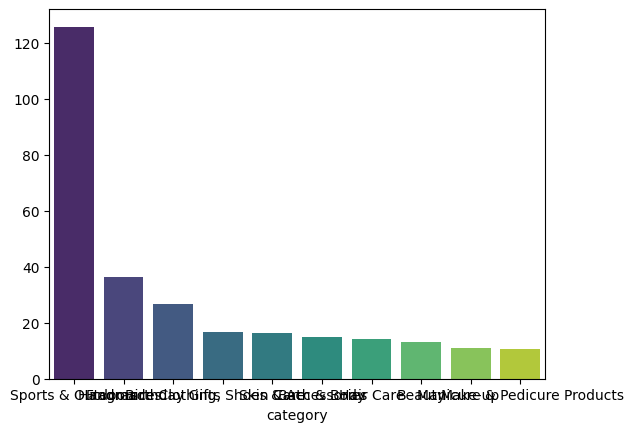

In [18]:
# avg_prices es una serie que tiene "1 indice" y "1 columna que son los valores"
sns.barplot(x=avg_prices.index, y=avg_prices.values, palette="viridis") 

  - Which product category commands the highest average price? Don't filter here by top categories.


In [19]:
highest_product = avg_prices.head(1)
highest_product

category
Sports & Outdoors    125.769814
Name: price, dtype: float64

---

3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots.  

    Filter out the top 10 categories based on count for better visualization.

In [20]:
df.head()


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


C:\Users\ernes\AppData\Local\Temp\ipykernel_30664\2165910660.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x='category', y='stars', palette="coolwarm")


<Axes: xlabel='category', ylabel='stars'>

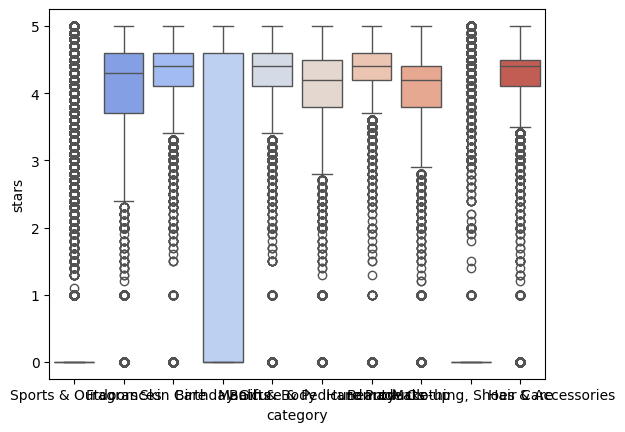

In [21]:
sns.boxplot(data=df_top10, x='category', y='stars', palette="coolwarm")

Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

In [22]:

customers_median = df_top10.groupby('category')['stars'].median().sort_values(ascending=False) # agrupa por categoria
                                                                                       # selecciona la columna stars
                                                                                       # calcula la mediana por categoria y stars
                                                                                       # ordena de maypr a menorhighest_product 
customers_median.head(1)

category
Bath & Body    4.4
Name: stars, dtype: float64

---

### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    

De este dataset, solo 3 variables sirven realmente para correlación:
stars  reviews  price

Pearson → si quieres ver si hay una recta

Spearman → si quieres ver si hay una tendencia

In [23]:
# Calculating the Pearson correlation coefficient between 'SalePrice' and 'GrLivArea' columns
correlation_Pearson = df['price'].corr(df['stars'], method='pearson')
print(f"correlation_Pearson: {correlation_Pearson}")
correlation_Sperarman = df['price'].corr(df['stars'], method='spearman')
print(f"correlation_Sperarman: {correlation_Sperarman}")

correlation_Pearson: -0.12490673262148386
correlation_Sperarman: -0.13316425462433876


- Is there a significant correlation between product price and its rating?

Son valores muy bajos,  
el Pearson como no esta ni cerca de 1 ni de -1 nos dice que no hay recta para ver relacion entre price y stars
el Spearman es tan bajo que tampoco indica tendencia que deberia ser cerca de -1 o 1

2. **Visualizations**:  
Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?

<Axes: xlabel='stars', ylabel='price'>

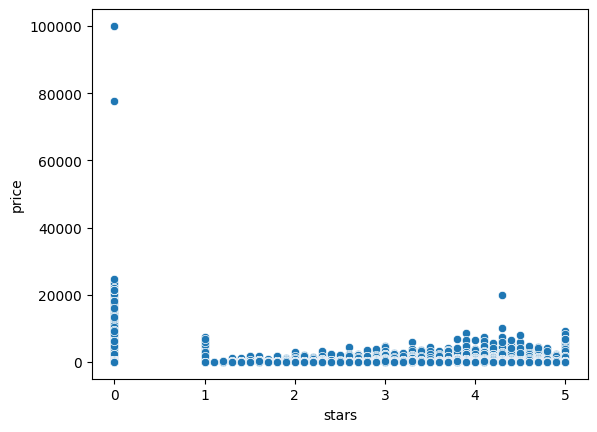

In [24]:
# Plotting a scatter plot to visualize the relationship between 'GrLivArea' and 'SalePrice'
sns.scatterplot(data=df, x='stars', y='price')

   - Use a correlation heatmap to visualize correlations between all numerical variables.



In [25]:
df.describe()

,uid,stars,reviews,price,boughtInLastMonth
count,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06
mean,1.370545e+06,2.152836e+00,4.806278e+02,8.924381e+01,2.589699e+01
std,8.160562e+05,2.194865e+00,5.944124e+03,3.456089e+02,2.404837e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.589215e+05,0.000000e+00,0.000000e+00,9.990000e+00,0.000000e+00
50%,1.349029e+06,0.000000e+00,0.000000e+00,1.909000e+01,0.000000e+00
75%,2.060686e+06,4.400000e+00,5.900000e+01,4.599000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.000000e+05,5.000000e+04


In [26]:
numericas = df.select_dtypes(include='number')
numericas

,uid,stars,reviews,price,boughtInLastMonth
0,1,4.7,15308,21.99,0
1,2,4.7,98099,23.99,0
2,3,4.7,15308,21.99,0
3,4,4.7,7205,31.99,0
4,5,4.6,1881,17.99,0
...,...,...,...,...,...
2443646,2828589,0.0,0,22.34,0
2443647,2828590,0.0,0,97.99,0
2443648,2828591,0.0,0,52.99,0
2443649,2828592,4.3,404,79.99,0


En el map-heat 

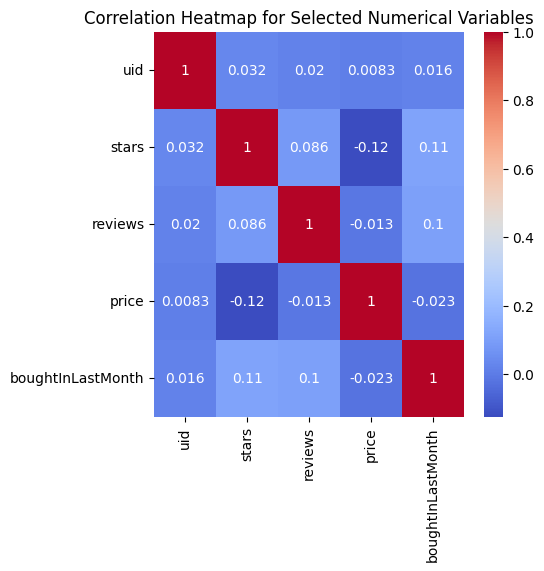

In [27]:
correlation_matrix = numericas.corr()

# Setting up the matplotlib figure with an appropriate size
plt.figure(figsize=(5, 5))  # Aqui ajuste el tamaño que 815,15) era enorme

# Drawing the heatmap for the numerical columns
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap for Selected Numerical Variables")
plt.show()

Con esos valores entre +0.086 y -0.023 no hay relación lineal ni tendencia entre ninguna de tus variables numéricas.
ni el precio influye en las estrellas
ni el precio influye en las rewies y todo igual

    - Examine if product prices typically follow a normal distribution using a QQ plot. 

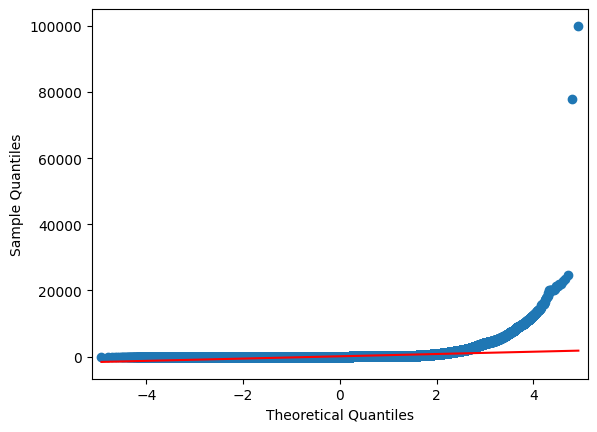

In [28]:
# aqui usamos la 
  
# Generating a Q-Q plot for 'SalePrice' to check if its distribution follows a normal distribution
sm.qqplot(df['price'], line='s');


- Do the same analysis without taking out the outliers. What are your insights?

In [29]:
def tukeys_test_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds for the outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify the outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    return outliers

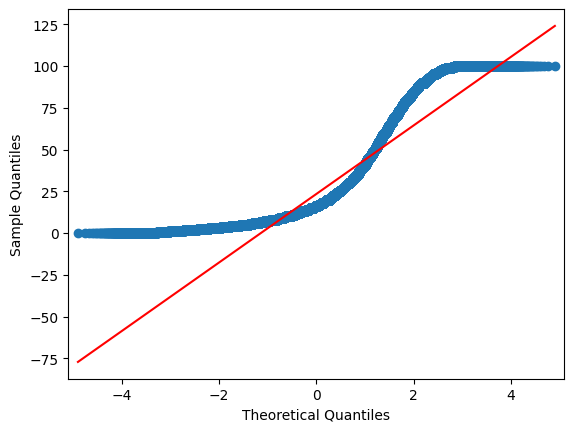

In [30]:
tukeys_test_outliers(df['price'])
df_clean = df.drop(outliers.index)
sm.qqplot(df_clean['price'], line='s');


Con outliers:  
- cuantiles extremos  
- escala enorme por que los ouliers son ENORMES  
- se nota donde estan los outliers en el extremo derecho de la grafica  

Sin outliers:  
- cuantiles más suaves  
- escala más pequeña  